In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("CityLine_Transit_20K_with_Routes.csv")

In [9]:
df.head()

,TripID,RouteID,BusID,StartTime,EndTime,FuelConsumed,Distance,TargetTime,ActualTime,DelayAnalysis,...,OTPFlag,EngineTemperature,RPM,FuelRate,BrakeEvents,RouteName,Source,Destination,RouteDistanceKM,RouteType
0,T000001,R139,B0199,24-09-2025 10:12,24-09-2025 11:19,14.39,80,64,67,3,...,On Time,71.79,1740,17.54,21,Route_139,Nizamabad,Karimnagar,80,Inter-City
1,T000002,R129,B0240,12-02-2025 08:13,12-02-2025 10:38,36.10,193,135,145,10,...,Delayed,104.70,1659,17.78,11,Route_129,Hyderabad,Khammam,193,Inter-City
2,T000003,R115,B0139,25-08-2025 10:07,25-08-2025 10:37,1.62,12,16,30,14,...,Delayed,73.95,2383,13.31,22,Route_115,SR Nagar,Banjara Hills,12,Urban
3,T000004,R143,B0122,25-03-2025 09:20,25-03-2025 11:58,12.03,120,124,158,34,...,Delayed,93.26,2189,10.54,18,Route_143,Hyderabad,Miryalaguda,120,Inter-City
4,T000005,R108,B0049,13-05-2025 06:09,13-05-2025 07:51,3.40,24,60,102,42,...,Delayed,85.11,2387,14.39,4,Route_108,Nagole,Kondapur,24,Urban


In [10]:
df.shape

(20000, 24)

In [11]:
df.columns

Index(['TripID', 'RouteID', 'BusID', 'StartTime', 'EndTime', 'FuelConsumed',
       'Distance', 'TargetTime', 'ActualTime', 'DelayAnalysis', 'IdleDuration',
       'AverageSpeed', 'OperatingCostPerKM', 'PassengerCount', 'OTPFlag',
       'EngineTemperature', 'RPM', 'FuelRate', 'BrakeEvents', 'RouteName',
       'Source', 'Destination', 'RouteDistanceKM', 'RouteType'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TripID              20000 non-null  object 
 1   RouteID             20000 non-null  object 
 2   BusID               20000 non-null  object 
 3   StartTime           20000 non-null  object 
 4   EndTime             20000 non-null  object 
 5   FuelConsumed        20000 non-null  float64
 6   Distance            20000 non-null  int64  
 7   TargetTime          20000 non-null  int64  
 8   ActualTime          20000 non-null  int64  
 9   DelayAnalysis       20000 non-null  int64  
 10  IdleDuration        20000 non-null  int64  
 11  AverageSpeed        20000 non-null  float64
 12  OperatingCostPerKM  20000 non-null  float64
 13  PassengerCount      20000 non-null  int64  
 14  OTPFlag             20000 non-null  object 
 15  EngineTemperature   20000 non-null  float64
 16  RPM 

In [14]:
df.describe

<bound method NDFrame.describe of         TripID RouteID  BusID         StartTime           EndTime  \
0      T000001    R139  B0199  24-09-2025 10:12  24-09-2025 11:19   
1      T000002    R129  B0240  12-02-2025 08:13  12-02-2025 10:38   
2      T000003    R115  B0139  25-08-2025 10:07  25-08-2025 10:37   
3      T000004    R143  B0122  25-03-2025 09:20  25-03-2025 11:58   
4      T000005    R108  B0049  13-05-2025 06:09  13-05-2025 07:51   
...        ...     ...    ...               ...               ...   
19995  T019996    R112  B0053  21-09-2025 16:20  21-09-2025 16:44   
19996  T019997    R140  B0192  16-06-2025 20:24  16-06-2025 21:12   
19997  T019998    R112  B0172  15-06-2025 22:23  15-06-2025 23:55   
19998  T019999    R106  B0047  10-04-2025 16:08  10-04-2025 17:30   
19999  T020000    R110  B0191  11-12-2025 18:07  11-12-2025 19:29   

       FuelConsumed  Distance  TargetTime  ActualTime  DelayAnalysis  ...  \
0             14.39        80          64          67       

In [15]:
df.isnull().sum()

TripID                0
RouteID               0
BusID                 0
StartTime             0
EndTime               0
FuelConsumed          0
Distance              0
TargetTime            0
ActualTime            0
DelayAnalysis         0
IdleDuration          0
AverageSpeed          0
OperatingCostPerKM    0
PassengerCount        0
OTPFlag               0
EngineTemperature     0
RPM                   0
FuelRate              0
BrakeEvents           0
RouteName             0
Source                0
Destination           0
RouteDistanceKM       0
RouteType             0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

TripID                 object
RouteID                object
BusID                  object
StartTime              object
EndTime                object
FuelConsumed          float64
Distance                int64
TargetTime              int64
ActualTime              int64
DelayAnalysis           int64
IdleDuration            int64
AverageSpeed          float64
OperatingCostPerKM    float64
PassengerCount          int64
OTPFlag                object
EngineTemperature     float64
RPM                     int64
FuelRate              float64
BrakeEvents             int64
RouteName              object
Source                 object
Destination            object
RouteDistanceKM         int64
RouteType              object
dtype: object

In [18]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['FuelConsumed', 'Distance', 'TargetTime', 'ActualTime', 'DelayAnalysis',
       'IdleDuration', 'AverageSpeed', 'OperatingCostPerKM', 'PassengerCount',
       'EngineTemperature', 'RPM', 'FuelRate', 'BrakeEvents',
       'RouteDistanceKM'],
      dtype='object')

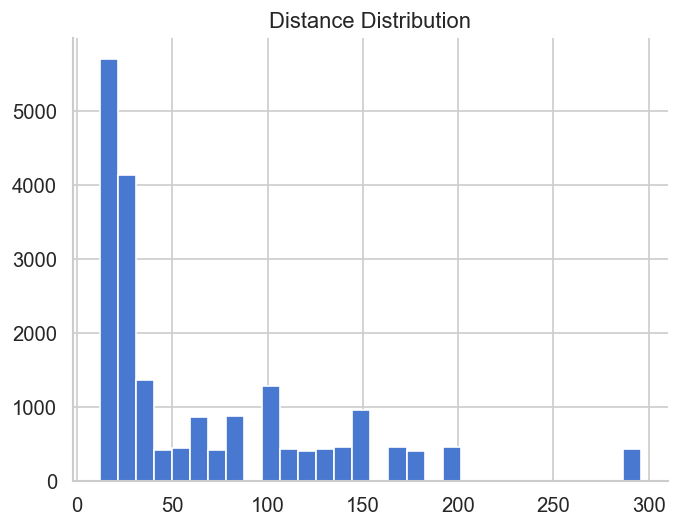

In [19]:
df['Distance'].hist(bins=30)
plt.title("Distance Distribution")
plt.show()

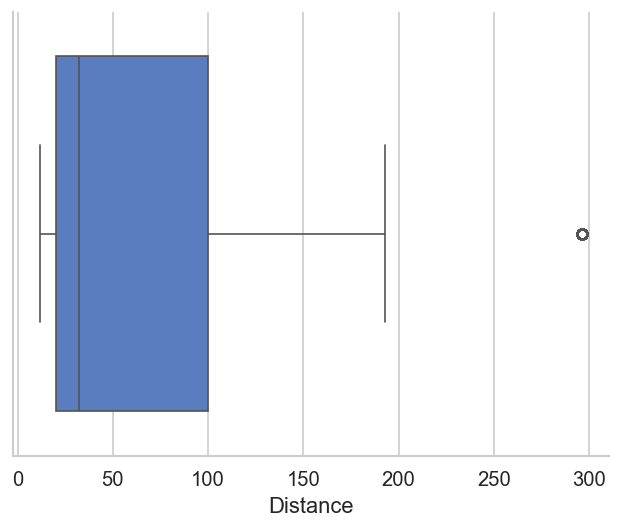

In [20]:
sns.boxplot(x=df['Distance'])
plt.show()

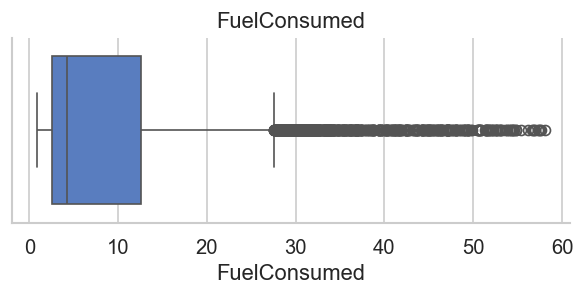

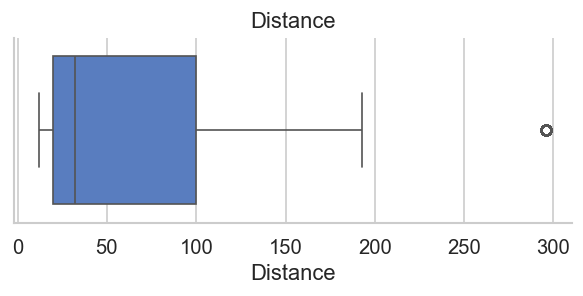

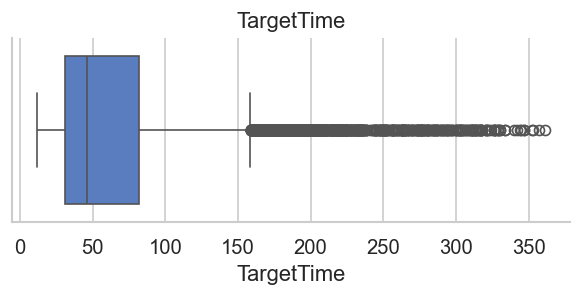

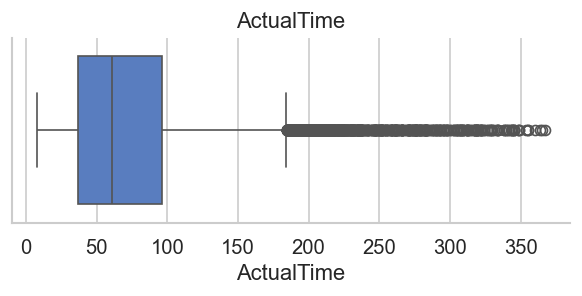

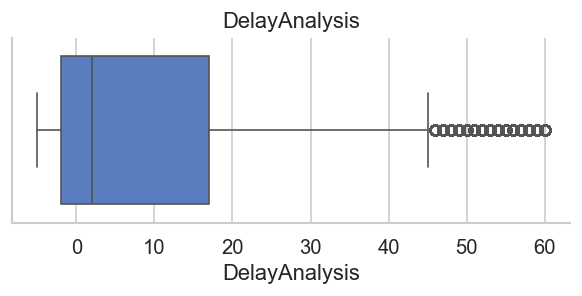

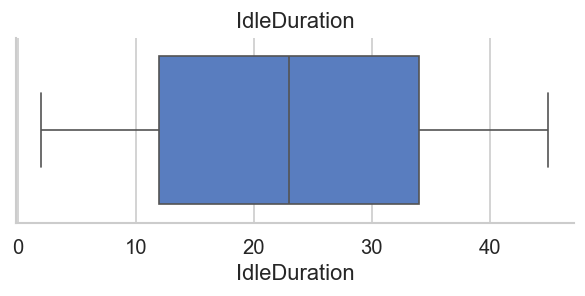

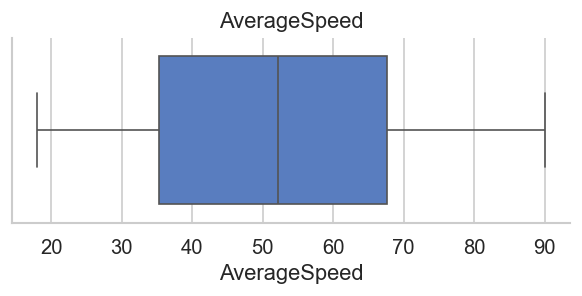

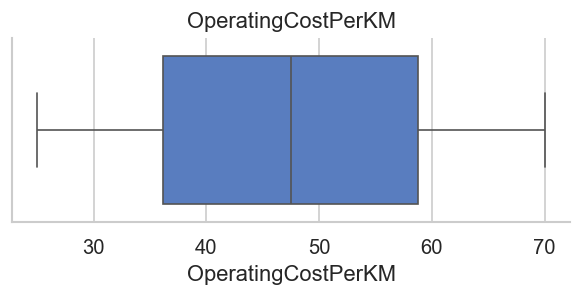

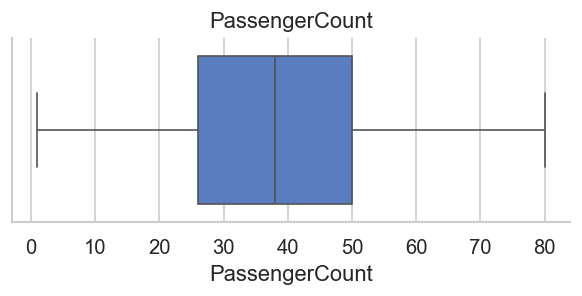

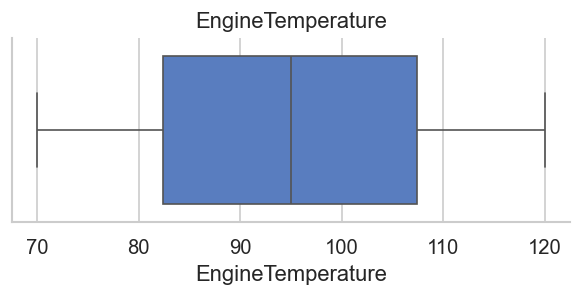

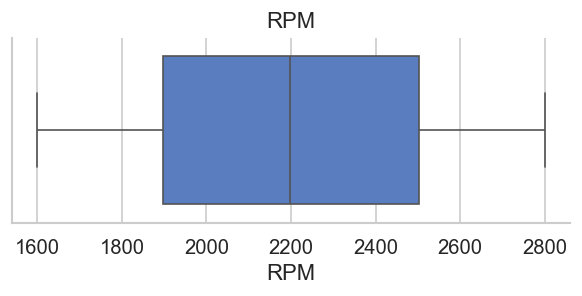

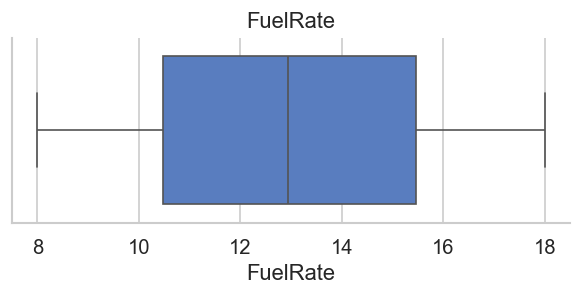

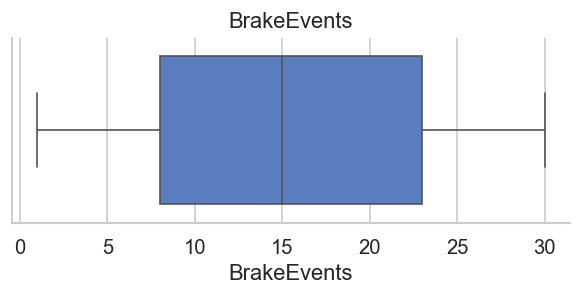

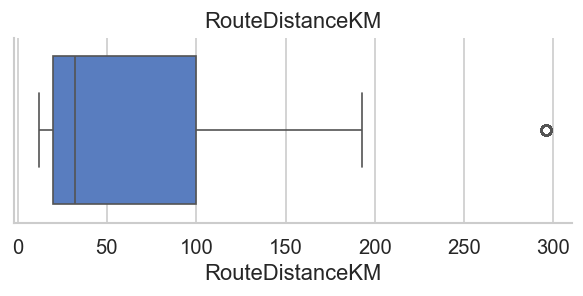

In [21]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [22]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['TripID', 'RouteID', 'BusID', 'StartTime', 'EndTime', 'OTPFlag',
       'RouteName', 'Source', 'Destination', 'RouteType'],
      dtype='object')

In [23]:
df['RouteName'].value_counts()

RouteName
Route_115    499
Route_117    499
Route_126    496
Route_123    485
Route_113    483
Route_128    467
Route_145    467
Route_118    466
Route_121    463
Route_119    463
Route_144    461
Route_129    455
Route_108    454
Route_122    450
Route_124    449
Route_102    448
Route_104    447
Route_110    447
Route_139    447
Route_142    447
Route_103    446
Route_114    444
Route_109    441
Route_138    441
Route_125    439
Route_136    438
Route_116    437
Route_132    436
Route_133    436
Route_101    435
Route_140    435
Route_134    431
Route_137    431
Route_105    430
Route_112    428
Route_120    428
Route_106    427
Route_135    427
Route_131    426
Route_141    417
Route_130    416
Route_107    416
Route_127    408
Route_143    403
Route_111    391
Name: count, dtype: int64

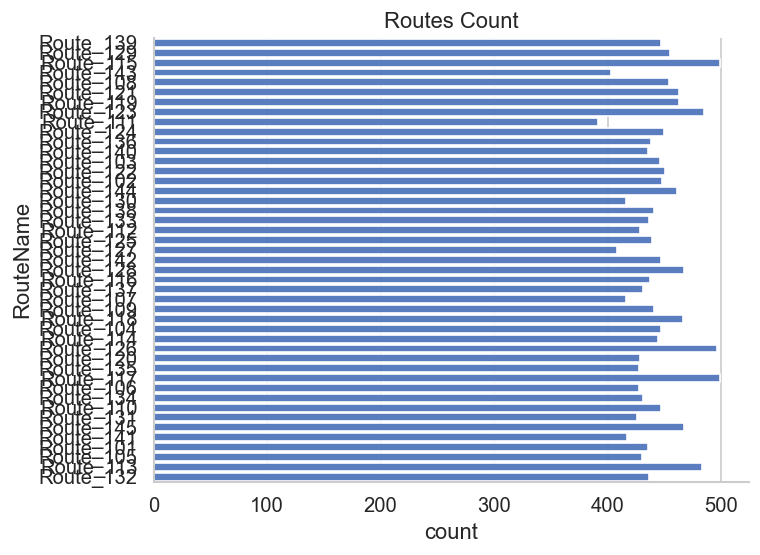

In [24]:
sns.countplot(y='RouteName', data=df)

plt.title("Routes Count")
plt.show()

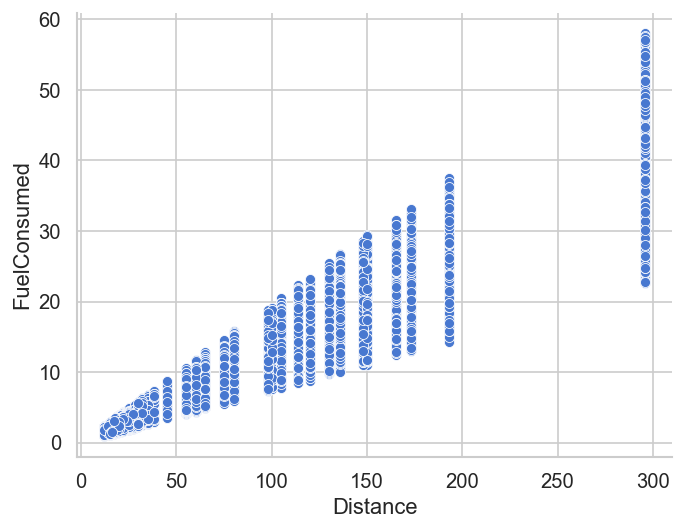

In [26]:
sns.scatterplot(
    x='Distance',
    y='FuelConsumed',
    data=df
)

plt.show()

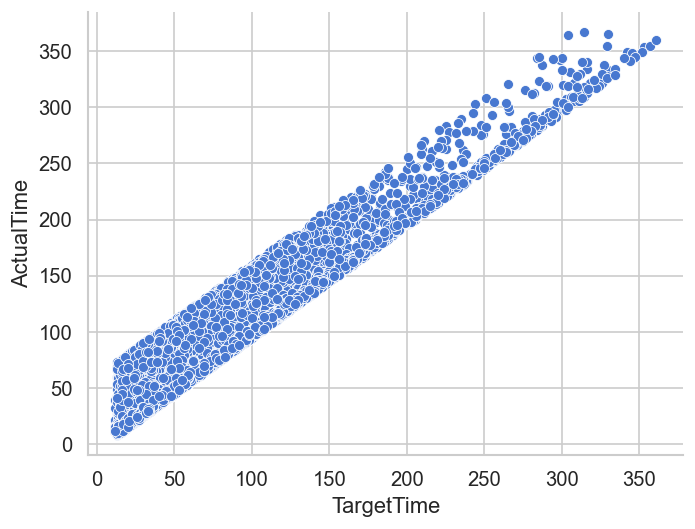

In [27]:
sns.scatterplot(
    x='TargetTime',
    y='ActualTime',
    data=df
)

plt.show()

In [28]:
num_df = df.select_dtypes(include='number')

In [29]:
corr_matrix = num_df.corr()

corr_matrix

,FuelConsumed,Distance,TargetTime,ActualTime,DelayAnalysis,IdleDuration,AverageSpeed,OperatingCostPerKM,PassengerCount,EngineTemperature,RPM,FuelRate,BrakeEvents,RouteDistanceKM
FuelConsumed,1.000000,0.948566,0.888975,0.818904,-0.100096,-0.001271,0.615364,-0.013866,-0.021151,-0.000273,-0.001749,0.228928,-0.011783,0.948566
Distance,0.948566,1.000000,0.938138,0.864321,-0.105280,-0.003521,0.649855,-0.013449,-0.021702,-0.001194,0.000960,0.008344,-0.012658,1.000000
TargetTime,0.888975,0.938138,1.000000,0.931193,-0.085224,-0.006669,0.401254,-0.014797,-0.010391,-0.001610,0.002260,0.006968,-0.015656,0.938138
ActualTime,0.818904,0.864321,0.931193,1.000000,0.283839,-0.006041,0.338955,-0.012059,-0.005648,-0.001304,0.005208,0.006893,-0.010346,0.864321
DelayAnalysis,-0.100096,-0.105280,-0.085224,0.283839,1.000000,0.001031,-0.129015,0.005962,0.011894,0.000669,0.008289,0.000510,0.012904,-0.105280
IdleDuration,-0.001271,-0.003521,-0.006669,-0.006041,0.001031,1.000000,-0.001184,0.000353,-0.006007,-0.008907,0.003589,0.002306,-0.002195,-0.003521
AverageSpeed,0.615364,0.649855,0.401254,0.338955,-0.129015,-0.001184,1.000000,-0.005961,-0.051198,-0.001544,-0.001354,0.005347,-0.005362,0.649855
OperatingCostPerKM,-0.013866,-0.013449,-0.014797,-0.012059,0.005962,0.000353,-0.005961,1.000000,-0.001011,0.002533,0.002651,-0.009843,0.009128,-0.013449
PassengerCount,-0.021151,-0.021702,-0.010391,-0.005648,0.011894,-0.006007,-0.051198,-0.001011,1.000000,-0.003179,-0.012138,0.001779,0.005438,-0.021702
EngineTemperature,-0.000273,-0.001194,-0.001610,-0.001304,0.000669,-0.008907,-0.001544,0.002533,-0.003179,1.000000,0.005831,-0.011247,-0.011562,-0.001194


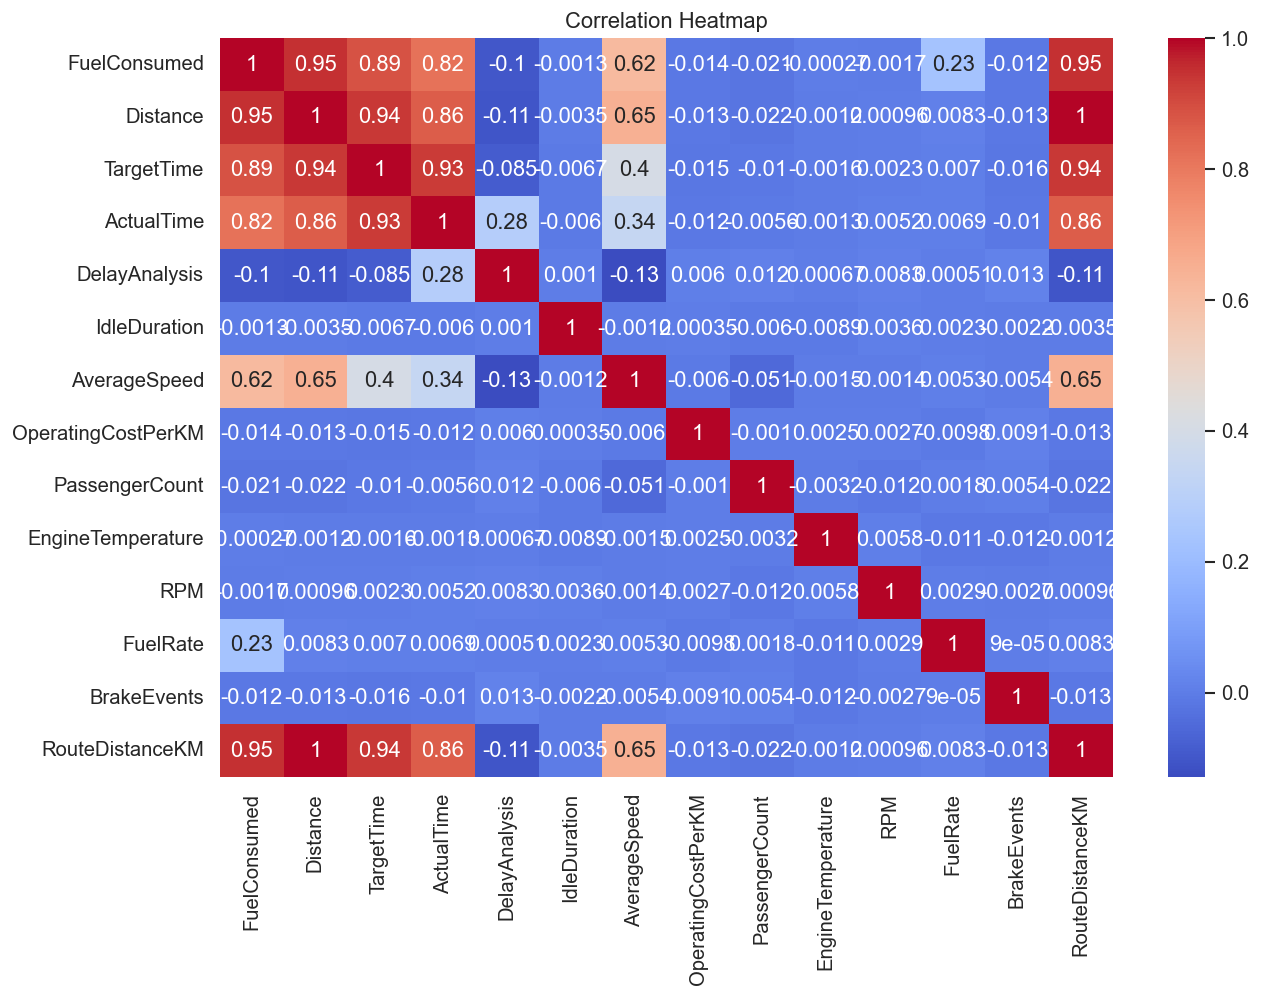

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

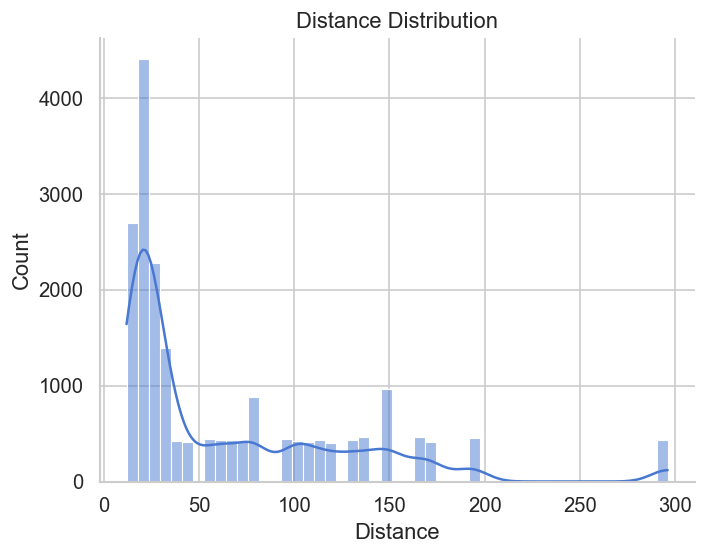

In [32]:
sns.histplot(
    df['Distance'],
    kde=True
)

plt.title("Distance Distribution")
plt.show()

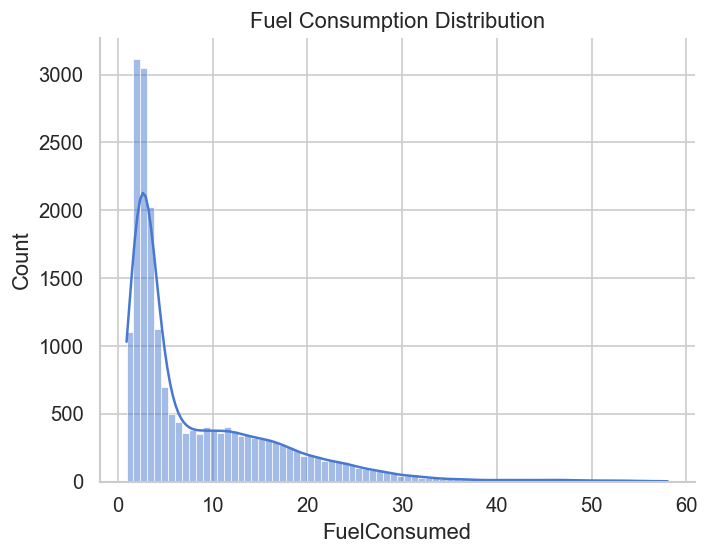

In [33]:
sns.histplot(
    df['FuelConsumed'],
    kde=True
)

plt.title("Fuel Consumption Distribution")
plt.show()

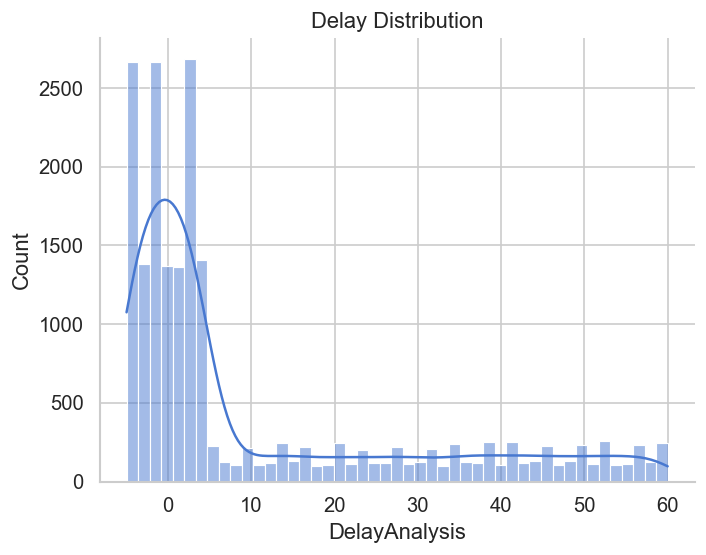

In [35]:
sns.histplot(
    df['DelayAnalysis'],
    kde=True
)

plt.title("Delay Distribution")
plt.show()